# CIS 3400 Advanced Programming
## Week 1: Google Colab Quick Start — Exploring Penguins

**Name:** *Mateo Berne*

Welcome to your first notebook for Advanced Programming!

In this short activity, you will practice using **Google Colab** while working with a real dataset. You will:

- run Python code in notebook cells,
- import Python libraries,
- read data into a pandas DataFrame,
- explore a dataset,
- create a visualization,
- write and use a simple function, and
- add Markdown notes to explain what you observe.

### How to work in Colab
Click a code cell and press the **Run** button (▶) or press **Shift + Enter**.

Work from the top of the notebook to the bottom so that variables and imports are created before later cells use them.

## 1. Import Python Libraries

Python libraries give us tools that have already been written for common programming tasks.

We will use:

- **pandas** for working with tabular data
- **matplotlib** for creating visualizations

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Read a Real Dataset

We will use the **Palmer Penguins** dataset. It contains measurements for penguins from three species observed in Antarctica.

The code below reads a CSV file from the web and stores it in a pandas **DataFrame** named `df`.

A DataFrame is similar to a table or spreadsheet: it has rows and columns.

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

print("Data loaded!")

Data loaded!


## 3. Take a Look at the Data

`head()` displays the first few rows of a DataFrame.

In [ ]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Now let's find out how large the dataset is.

`shape` returns:

**(number of rows, number of columns)**

In [ ]:
df.shape

(344, 7)

### YOUR TURN #1

In the Markdown cell below, record how many **rows** and **columns** are in the dataset.

**My answer:**  
Rows:  344
Columns: 7

## 4. Explore the Data

`describe()` gives us summary statistics for the numeric columns.

In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


We can also see how many penguins belong to each species.

In [ ]:
df["species"].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


### YOUR TURN #2

Change `"species"` in the code below to `"island"` and run the cell.

How many penguins were observed on each island?

In [ ]:
df["island"].value_counts()

,count
island,
Biscoe,168
Dream,124
Torgersen,52


## 5. Filter the Data

We can select only rows that meet a condition.

The code below creates a new DataFrame containing only **Adelie** penguins.

In [ ]:
adelie = df[df["species"] == "Gentoo"]

adelie.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
220,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,FEMALE
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,MALE
222,Gentoo,Biscoe,48.7,14.1,210.0,4450.0,FEMALE
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,MALE
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,MALE


### YOUR TURN #3

Change `"Adelie"` to either `"Gentoo"` or `"Chinstrap"` and run the cell again.

## 6. Create a Visualization

Let's look at the relationship between a penguin's **flipper length** and **body mass**.

A scatter plot is useful when we want to compare two numeric variables.

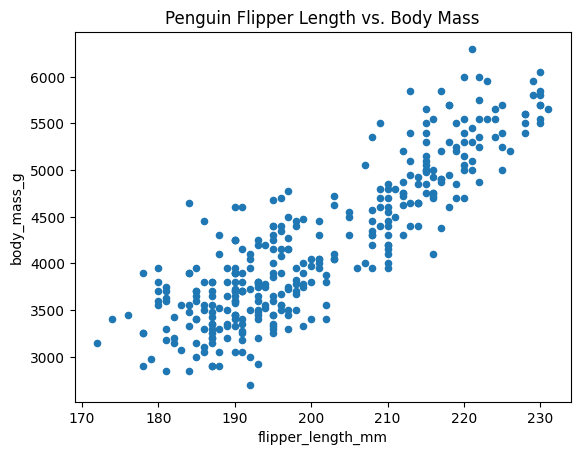

In [ ]:
df.plot.scatter(
    x="flipper_length_mm",
    y="body_mass_g",
    title="Penguin Flipper Length vs. Body Mass"
)

plt.show()

### What do you notice?

Add **one sentence** below describing something you notice in the graph.

**My observation:**  
Penguins with longer flippers tend to have a higher body mass.

## 7. Write a Simple Function

Functions let us package code into a reusable operation.

The dataset records body mass in **grams**. Let's write a function that converts grams to kilograms.

In [ ]:
def grams_to_kg(grams):
    return grams / 1000

Now call the function:

In [ ]:
grams_to_kg(5000)

5.0

We can even use the function with a value from our dataset.

In [ ]:
first_penguin_mass = df.loc[0, "body_mass_g"]

print("Mass in grams:", first_penguin_mass)
print("Mass in kilograms:", grams_to_kg(first_penguin_mass))

Mass in grams: 3750.0
Mass in kilograms: 3.75


### YOUR TURN #4

Call `grams_to_kg()` with a value of your choice.

In [ ]:
# Replace 4200 with a value of your choice
grams_to_kg(6000)

6.0

## 8. One Last Look

Let's display the average numeric measurements for each penguin species.

In [ ]:
df.groupby("species").mean(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


## 9. Build a Predictive Model

So far we have described the penguins we already measured.

Now we will build a **machine learning model** that tries to predict something we do *not* already know: given a penguin's measurements, which **species** is it?

The idea is simple:

1. Show the model a set of penguins where we already know the species (the **training** data).
2. Hide a second set of penguins from it (the **testing** data).
3. Ask the model to predict the species of the hidden penguins.
4. Compare its predictions to the real answers and score how well it did.

We are previewing an idea here that we will study in depth later in the semester. For today, focus on *reading* the code and being able to say what each line is doing.

### 9.1 Import the Machine Learning Tools

`scikit-learn` (imported as `sklearn`) is Python's standard machine learning library. It is already installed in Colab.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("Machine learning tools imported!")

Machine learning tools imported!


### 9.2 Handle the Missing Values

Look back at row 3 of the dataset. Several columns contain `NaN`, which means the value is **missing**.

A model cannot train on missing values, so we need to deal with them. The simplest option is to drop any row that has a missing value.

`dropna()` returns a new DataFrame with those rows removed.

In [ ]:
model_df = df.dropna()

print("Rows before dropping missing values:", len(df))
print("Rows after dropping missing values: ", len(model_df))
print("Rows removed:", len(df) - len(model_df))

Rows before dropping missing values: 344
Rows after dropping missing values:  333
Rows removed: 11


### 9.3 Choose the Target and the Features

Two terms we will use all semester:

- The **target** (`y`) is the thing we are trying to predict. Here it is `species`.
- The **features** (`X`) are the pieces of information the model gets to look at.

One complication: a model does math, so it cannot work with text like `"Biscoe"` or `"MALE"` directly. `pd.get_dummies()` converts each text category into its own True/False column. This is called **one-hot encoding**.

In [ ]:
target_column = "sex"

feature_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "species"
]

y = model_df[target_column]
X = model_df[feature_columns]

# Turn the text columns into numeric True/False columns
X = pd.get_dummies(X, columns=["species"])

X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo
0,39.1,18.7,181.0,3750.0,True,False,False
1,39.5,17.4,186.0,3800.0,True,False,False
2,40.3,18.0,195.0,3250.0,True,False,False
4,36.7,19.3,193.0,3450.0,True,False,False
5,39.3,20.6,190.0,3650.0,True,False,False


Notice that `island` and `sex` are gone, replaced by a set of new columns.

Note that `species` is **not** in `X`. If we gave the model the answer as a feature, it would score perfectly and would have learned nothing.

In [ ]:
print("Number of features:", X.shape[1])
print()
print("Feature names:")
for name in X.columns:
    print(" -", name)

Number of features: 7

Feature names:
 - bill_length_mm
 - bill_depth_mm
 - flipper_length_mm
 - body_mass_g
 - species_Adelie
 - species_Chinstrap
 - species_Gentoo


### 9.4 Split the Data into Training and Testing Sets

We hold back part of the data so we can test the model on penguins it has never seen.

- `test_size=0.25` holds back 25% of the rows for testing.
- `random_state=42` makes the split reproducible, so everyone in class gets the same result.
- `stratify=y` keeps the mix of species roughly the same in both halves.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))
print()
print("Species in the training set:")
print(y_train.value_counts())

Training rows: 249
Testing rows:  84

Species in the training set:
sex
MALE      126
FEMALE    123
Name: count, dtype: int64


### 9.5 Train the Model

We will use a **Random Forest**, which builds a large collection of decision trees and lets them vote on the answer.

`fit()` is the step where the model actually learns. It only ever sees the training data.

In [ ]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

print("Model trained!")
print("Species this model can predict:", model.classes_)

Model trained!
Species this model can predict: ['FEMALE' 'MALE']


### 9.6 Make Predictions

`predict()` returns the single species the model thinks is most likely.

`predict_proba()` returns the model's confidence in *each* species. We need those probabilities later to compute AUC.

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Put the real answers and the predictions side by side
comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

comparison.head(10)

,actual,predicted
0,FEMALE,FEMALE
1,MALE,MALE
2,MALE,MALE
3,FEMALE,FEMALE
4,MALE,MALE
5,MALE,MALE
6,MALE,MALE
7,MALE,MALE
8,FEMALE,FEMALE
9,MALE,MALE


### 9.7 Evaluate the Model

Now we score the predictions against the real answers. Each metric answers a slightly different question:

- **Accuracy** — of all the test penguins, what fraction did we get right?
- **Precision** — when the model said "Gentoo," how often was it actually a Gentoo?
- **Recall** — of all the real Gentoos, how many did the model find?
- **F1 score** — a single number that balances precision and recall.
- **AUC** — how well the model separates one species from the others across all confidence levels. 1.0 is perfect, 0.5 is a coin flip.

Because we have three species instead of two, we ask for the `macro` average, which computes the metric for each species and then averages them, treating all three species as equally important.

In [ ]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, average="macro"), 3))
print("Recall   :", round(recall_score(y_test, y_pred, average="macro"), 3))
print("F1 score :", round(f1_score(y_test, y_pred, average="macro"), 3))
print("AUC      :", round(roc_auc_score(y_test, y_proba[:, 1]), 3))

Accuracy : 0.917
Precision: 0.919
Recall   : 0.917
F1 score : 0.917
AUC      : 0.956


We can also get precision, recall, and F1 broken out **for each species** in one table.

The `support` column tells us how many test penguins of that species there were.

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      FEMALE       0.95      0.88      0.91        42
        MALE       0.89      0.95      0.92        42

    accuracy                           0.92        84
   macro avg       0.92      0.92      0.92        84
weighted avg       0.92      0.92      0.92        84



### YOUR TURN #5

In the Markdown cell below, record the accuracy and the AUC, then answer this question:

Does a score this high make you trust the model *more* or *less*? Why?

**My answer:**  
Accuracy: 0.917
AUC:  0.956
What I think about that score: I trust the model more because the accuracy and AUC scores are both high.

### 9.8 Confusion Matrix

A **confusion matrix** shows exactly *where* the model was right and where it was wrong.

Read it like this: each **row** is the species a penguin really was, and each **column** is the species the model guessed. Correct predictions land on the diagonal running from the top left to the bottom right. Anything off that diagonal is a mistake.

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# As a table
cm_table = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)
print("Rows = actual species, Columns = predicted species")
print(cm_table)

Rows = actual species, Columns = predicted species
        FEMALE  MALE
FEMALE      37     5
MALE         2    40


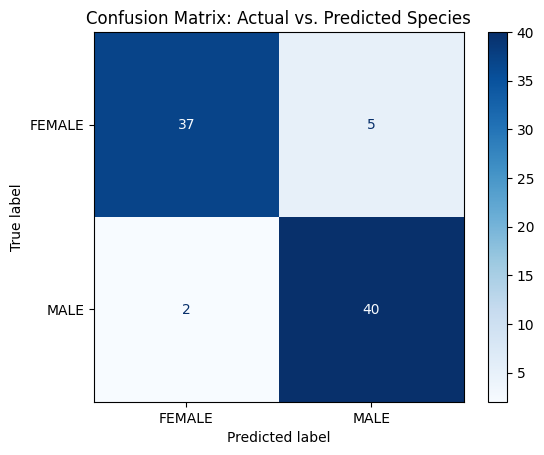

In [ ]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

display.plot(cmap="Blues")
plt.title("Confusion Matrix: Actual vs. Predicted Species")
plt.show()

### 9.9 Feature Importance

The model can tell us which features it leaned on most when making its decisions.

`feature_importances_` gives one number per feature. They add up to 1.0, so a feature with an importance of 0.35 accounted for about 35% of the model's decision making.

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances.round(3))

bill_depth_mm        0.300
body_mass_g          0.296
bill_length_mm       0.228
flipper_length_mm    0.112
species_Adelie       0.029
species_Gentoo       0.021
species_Chinstrap    0.014
dtype: float64


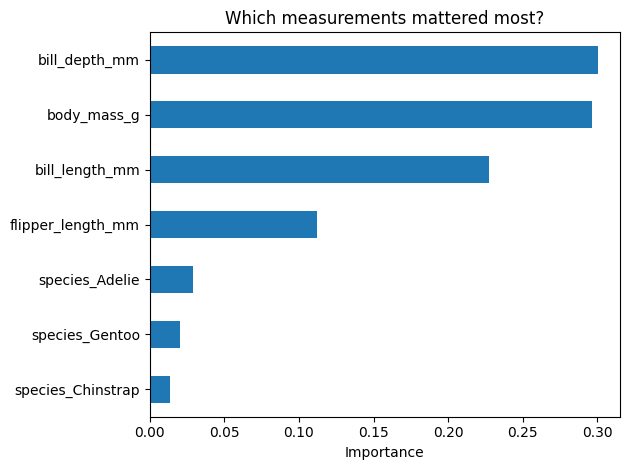

In [ ]:
importances.sort_values().plot.barh(
    title="Which measurements mattered most?"
)

plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### YOUR TURN #6

Which feature was the most important? Which was the least important?

Look back at the scatter plot in Section 6. Does the ranking match what you saw there?

**My answer:**  
Most important feature: bill_depth_mm
Least important feature:  species_Chinstrap
Does this match the scatter plot? Yes, a bit. The scatter plot displayed a relationship between flipper length and body mass, but the model identified bill depth as the most significant feature.

### 9.10 Predict a Brand New Penguin

A model is only useful if we can hand it something new.

Below we invent a penguin that is not in the dataset and ask the model to classify it.

One detail matters here: the new penguin has to be described with **exactly the same columns, in the same order**, that the model was trained on. `reindex()` lines the columns up and fills in any missing category column with 0.

In [ ]:
new_penguin = pd.DataFrame([{
    "island": "Biscoe",
    "bill_length_mm": 46.0,
    "bill_depth_mm": 16.0,
    "flipper_length_mm": 215.0,
    "body_mass_g": 5000.0,
    "sex": "MALE"
}])

# Encode it the same way we encoded the training data
new_penguin = pd.get_dummies(new_penguin, columns=["island", "sex"])
new_penguin = new_penguin.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_penguin)[0]
probabilities = pd.Series(model.predict_proba(new_penguin)[0], index=model.classes_)

print("Predicted species:", prediction)
print()
print("How confident the model is:")
print(probabilities.round(3))

Predicted species: MALE

How confident the model is:
FEMALE    0.45
MALE      0.55
dtype: float64


### YOUR TURN #7

Change the measurements above to describe a different penguin and run the cell again.

Can you find a set of measurements where the model is **not** confident, meaning no single species gets a probability close to 1.0?

### 9.11 A Score That Is Too Good

Our first model scored almost perfectly. That should raise an eyebrow, not a cheer. Real world data is rarely that tidy, and a perfect score usually means the problem was easy, not that the model was brilliant.

Here the problem really is easy: the three species have noticeably different bills and flippers, so they are simple to tell apart.

To see the difference, let's retrain the exact same model using only **two** weak features and watch the scores fall apart.

In [ ]:
weak_features = ["flipper_length_mm", "bill_length_mm"]

X_weak = model_df[weak_features]

X_weak_train, X_weak_test, y_train2, y_test2 = train_test_split(
    X_weak,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

weak_model = RandomForestClassifier(n_estimators=200, random_state=42)
weak_model.fit(X_weak_train, y_train2)

y_weak_pred = weak_model.predict(X_weak_test)
y_weak_proba = weak_model.predict_proba(X_weak_test)

print("Accuracy :", round(accuracy_score(y_test2, y_weak_pred), 3))
print("F1 score :", round(f1_score(y_test2, y_weak_pred, average="macro"), 3))
print("AUC      :", round(roc_auc_score(y_test2, y_weak_proba[:, 1]), 3))
print()
print(classification_report(y_test2, y_weak_pred))

Accuracy : 0.738
F1 score : 0.736
AUC      : 0.836

              precision    recall  f1-score   support

      FEMALE       0.79      0.64      0.71        42
        MALE       0.70      0.83      0.76        42

    accuracy                           0.74        84
   macro avg       0.75      0.74      0.74        84
weighted avg       0.75      0.74      0.74        84



In [ ]:
cm_weak = confusion_matrix(y_test2, y_weak_pred, labels=weak_model.classes_)

print("Rows = actual species, Columns = predicted species")
print(pd.DataFrame(cm_weak, index=weak_model.classes_, columns=weak_model.classes_))

Rows = actual species, Columns = predicted species
        FEMALE  MALE
FEMALE      27    15
MALE         7    35


### Discussion

Look at the confusion matrix from the weaker model.

- One species is still predicted almost perfectly. Which one, and why might that be? The model predicts males better than females.
- Two species get mixed up with each other constantly. Which two? Females and males are sometimes confused because their measurements can overlap.
- Notice that accuracy alone hides this problem. The per-species report and the confusion matrix are what reveal it.

This is the reason we never judge a model by a single number.

## Finished!

You have now used Google Colab to:

- run Python code,
- import libraries,
- load a CSV file,
- explore a pandas DataFrame,
- filter data,
- make a visualization,
- write a function,
- document your work using Markdown,
- train a predictive model, and
- evaluate that model and inspect its mistakes.

### Submit in Blackboard

Before submitting:

1. Make sure your **name** is at the top.
2. Make sure you completed all **YOUR TURN** sections.
3. From Colab, choose **File → Download → Download .ipynb**.
4. Submit the `.ipynb` file in Blackboard.

**Grading:** Completion and reasonable effort.